In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from task_2_3 import (
    calculate_returns,
    rolling_window_analysis,
    expanding_window_analysis
)

#plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 100)

import warnings
warnings.filterwarnings('ignore')

### 1. Загрузка и обработка данных

In [2]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    
    df.columns = df.columns.str.strip()
    df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
    df.set_index('date', inplace=True)

    df = df.replace('', np.nan).replace(' ', np.nan) \
            .dropna(how='all') \
            .dropna(axis=1, how='all')
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

In [3]:
def load_prices_data(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path, sep=';', decimal=',')

    return preprocess_data(df)

In [5]:
stoks_prices_df = load_prices_data("prices_moex_new.csv")

Информация о данных

In [6]:
print(f"Размер: {stoks_prices_df.shape}")
print(f"Период: {stoks_prices_df.index.min()} - {stoks_prices_df.index.max()}")
print(f"Количество акций: {len(stoks_prices_df.columns)}")
print(f"\nСписок акций: {list(stoks_prices_df.columns)}")

Размер: (2763, 30)
Период: 2015-01-05 00:00:00 - 2025-12-30 00:00:00
Количество акций: 30

Список акций: ['SBER', 'SBERP', 'GAZP', 'LKOH', 'ROSN', 'NVTK', 'TATN', 'TATNP', 'SNGS', 'SNGSP', 'GMKN', 'CHMF', 'NLMK', 'MAGN', 'MTSS', 'AFLT', 'VTBR', 'MOEX', 'PLZL', 'ALRS', 'MGNT', 'PHOR', 'AKRN', 'FEES', 'HYDR', 'IRAO', 'BSPB', 'TRNFP', 'SIBN', 'LSRG']


### 2. Векторы доходностей и ковариационные матрицы на различные даты

#### Доходности

In [7]:
returns = calculate_returns(stoks_prices_df)

Визуализация кумулятивных доходностей для первых 5 акций

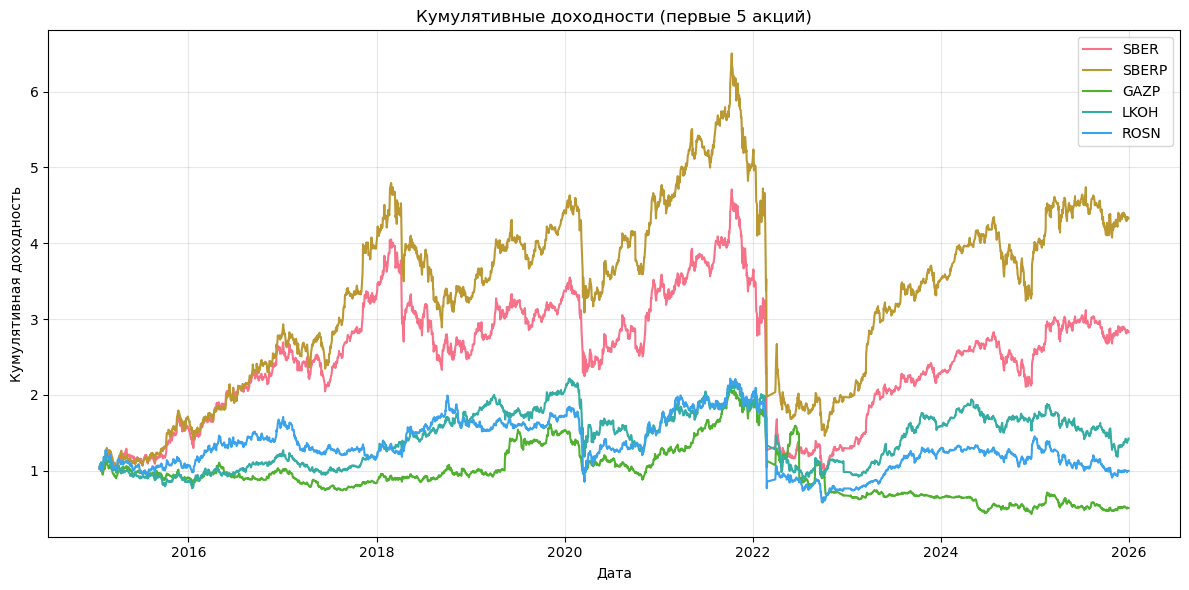

In [8]:
plt.figure(figsize=(12, 6))
for col in returns.columns[:5]:
    cumulative_returns = (1 + returns[col]).cumprod()
    plt.plot(returns.index, cumulative_returns, label=col)

plt.title('Кумулятивные доходности (первые 5 акций)')
plt.xlabel('Дата')
plt.ylabel('Кумулятивная доходность')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2.a Скользящее окно

In [9]:
rolling_results = rolling_window_analysis(returns, window_size='1Y', step_size='1Y')

In [10]:
print(f"\nПолучено окон: {len(rolling_results)}")

if rolling_results:
    first_date = list(rolling_results.keys())[0]
    first_result = rolling_results[first_date]
    
    print(f"\n--- Первое окно ---")
    print(f"Период: {first_result['window_start'].strftime('%Y-%m-%d')} - {first_date.strftime('%Y-%m-%d')}")
    print(f"Размер окна: {len(first_result['window_returns'])} наблюдений")
    print(f"Размер ковариационной матрицы: {first_result['covariance_matrix'].shape}")
    
    # Проверка ковариационной матрицы
    cov_matrix = first_result['covariance_matrix']
    print(f"\nСвойства ковариационной матрицы:")
    print(f"- Симметричность: {np.allclose(cov_matrix, cov_matrix.T)}")
    print(f"- Определитель: {np.linalg.det(cov_matrix):.6e}")


Получено окон: 10

--- Первое окно ---
Период: 2015-01-21 - 2016-01-21
Размер окна: 251 наблюдений
Размер ковариационной матрицы: (30, 30)

Свойства ковариационной матрицы:
- Симметричность: True
- Определитель: 2.870323e-106


Визуализация динамики средних доходностей во времени

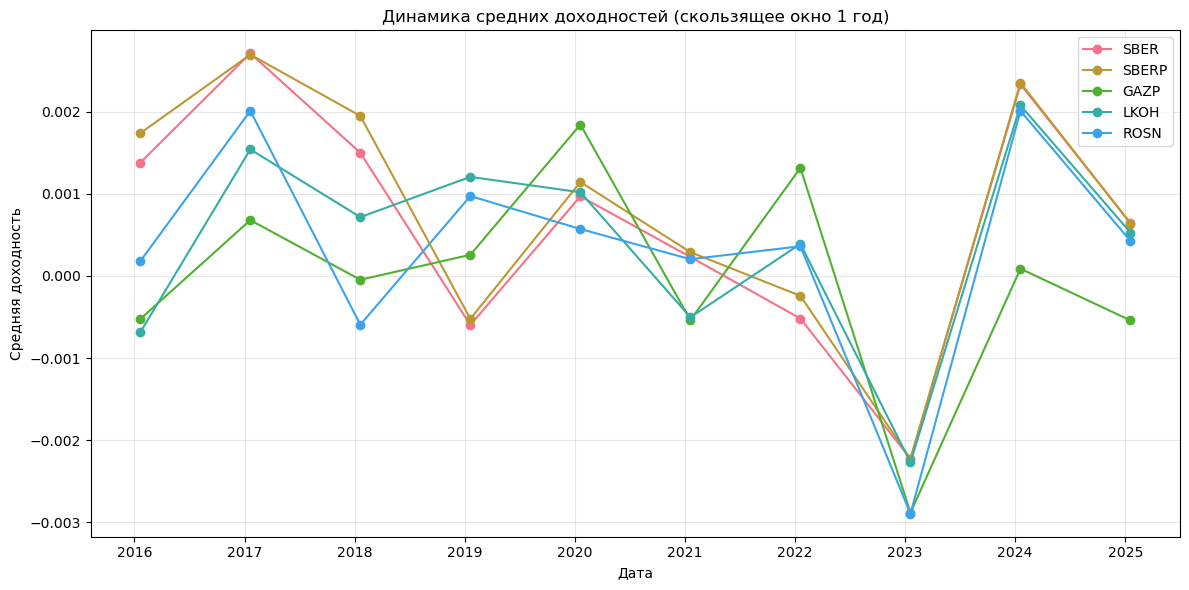

In [11]:
if rolling_results:
    dates = list(rolling_results.keys())
    mean_returns_history = [rolling_results[date]['mean_returns'] for date in dates]
    mean_returns_df = pd.DataFrame(mean_returns_history, index=dates, columns=returns.columns)
    
    plt.figure(figsize=(12, 6))
    for col in returns.columns[:5]:
        plt.plot(mean_returns_df.index, mean_returns_df[col], marker='o', label=col)
    
    plt.title('Динамика средних доходностей (скользящее окно 1 год)')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Выводы**:
- Определитель матрицы очень мал (~2.87e-106), что характерно для 30x30 матрицы с сильной корреляцией активов
- Средние доходности не стабильны во времени - это демонстрирует, что историческая доходность — ненадежный прогноз будущего

#### 2.a Расширяющее окно

In [12]:
expanding_results = expanding_window_analysis(returns, step_size='1Y')

In [13]:
print(f"\nПолучено окон: {len(expanding_results)}")

if expanding_results:
    print("\n--- Динамика размера окна ---")
    for i, (date, result) in enumerate(list(expanding_results.items())[:5]):
        print(f"Окно {i+1}:  {date.strftime('%Y-%m-%d')} - {result['window_size']} наблюдений")
    print("...")
    
    last_date = list(expanding_results.keys())[-1]
    last_result = expanding_results[last_date]
    print(f"Окно {len(expanding_results)}: {last_date.strftime('%Y-%m-%d')} - {last_result['window_size']} наблюдений")


Получено окон: 10

--- Динамика размера окна ---
Окно 1:  2016-01-21 - 251 наблюдений
Окно 2:  2017-01-20 - 505 наблюдений
Окно 3:  2018-01-20 - 755 наблюдений
Окно 4:  2019-01-20 - 1008 наблюдений
Окно 5:  2020-01-20 - 1260 наблюдений
...
Окно 10: 2025-01-18 - 2475 наблюдений


Сравнение скользящего и расширяющегося окон

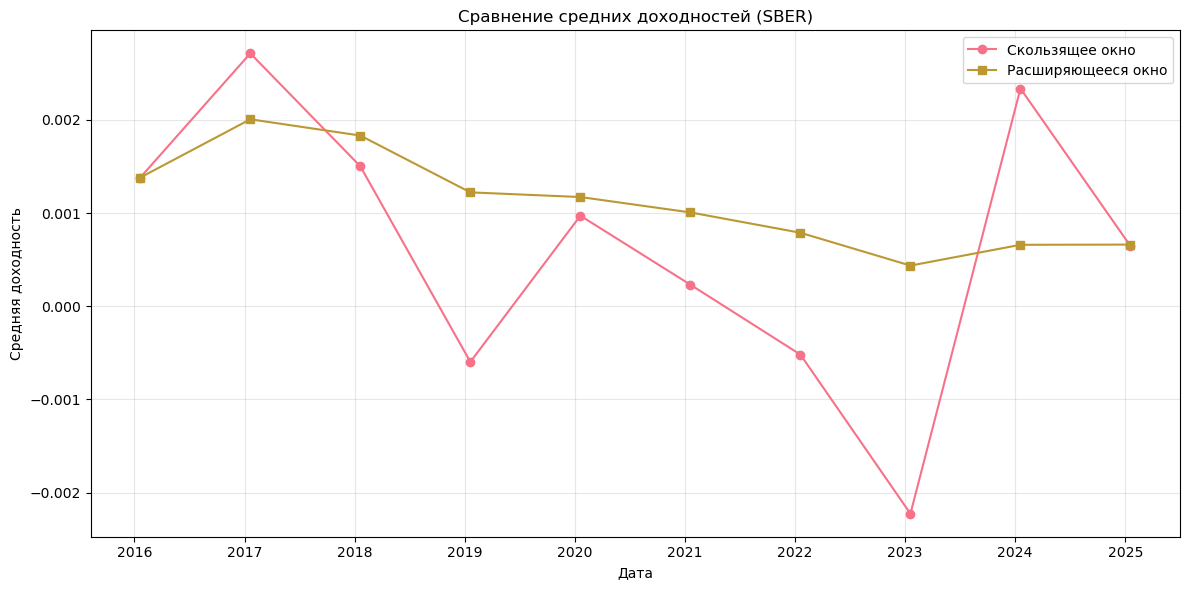

In [14]:
if rolling_results and expanding_results:
    rolling_dates = list(rolling_results.keys())
    expanding_dates = list(expanding_results.keys())
    
    ticker = returns.columns[0]
    
    rolling_means = [rolling_results[date]['mean_returns'][0] for date in rolling_dates]
    expanding_means = [expanding_results[date]['mean_returns'][0] for date in expanding_dates]
    
    plt.figure(figsize=(12, 6))
    plt.plot(rolling_dates, rolling_means, marker='o', label='Скользящее окно')
    plt.plot(expanding_dates, expanding_means, marker='s', label='Расширяющееся окно')
    plt.title(f'Сравнение средних доходностей ({ticker})')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

**Выводы**:
- Скользящее окно реагирует быстрее на изменения рыночной ситуации (использует только свежие данные)
- Расширяющееся окно более стабильно (учитывает всю историю), но может отставать от текущих трендов
- Для краткосрочных прогнозов скользящее окно может быть предпочтительнее
- Для долгосрочных оценок — расширяющееся окно

### 3. Экспоненциальное забывание

- Скользящее окно (1 год)
- lambda=0.94

In [15]:
rolling_exp_results = rolling_window_analysis(
    returns, window_size='1Y', step_size='1Y', lambda_param=0.94
)

Сравнение обычного и экспоненциального взвешивания

Получено окон: 10


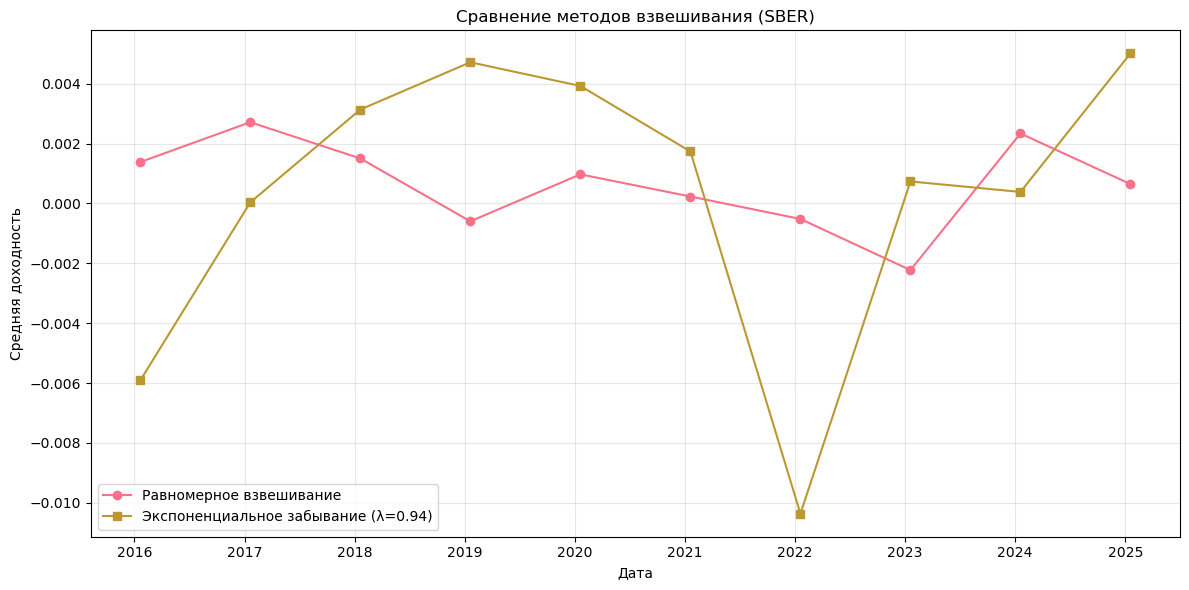


--- Численное сравнение для первой даты ---
Дата: 2016-01-21
Равномерное взвешивание: 0.001382
Экспоненциальное забывание: -0.005912
Разница: -0.007294


In [16]:
print(f"Получено окон: {len(rolling_exp_results)}")

if rolling_results and rolling_exp_results:
    ticker = returns.columns[0]
    ticker_idx = 0
    
    dates = list(rolling_results.keys())
    rolling_means = [rolling_results[date]['mean_returns'][ticker_idx] for date in dates]
    exp_means = [rolling_exp_results[date]['mean_returns'][ticker_idx] for date in dates]
    
    plt.figure(figsize=(12, 6))
    plt.plot(dates, rolling_means, marker='o', label='Равномерное взвешивание')
    plt.plot(dates, exp_means, marker='s', label='Экспоненциальное забывание (λ=0.94)')
    plt.title(f'Сравнение методов взвешивания ({ticker})')
    plt.xlabel('Дата')
    plt.ylabel('Средняя доходность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n--- Численное сравнение для первой даты ---")
    first_date = dates[0]
    print(f"Дата: {first_date.strftime('%Y-%m-%d')}")
    print(f"Равномерное взвешивание: {rolling_means[0]:.6f}")
    print(f"Экспоненциальное забывание: {exp_means[0]:.6f}")
    print(f"Разница: {exp_means[0] - rolling_means[0]:.6f}")

**Выводы:**
- Экспоненциальное забывание дает оценки, отличные от равномерного взвешивания
- Различия зависят от конкретной даты и динамики цен
- В периоды стабильности различия могут быть минимальными
- В периоды сильных изменений экспоненциальное забывание быстрее адаптируется

### Общие выводы по блоку
1) Нестабильность оценок: Доходности и риски акций значительно меняются во времени, поэтому статичные оценки могут быть ошибочными
2) Выбор метода взвешивания:
    - Для краткосрочных прогнозов: экспоненциальное забывание или скользящее окно
    - Для долгосрочных стратегий: расширяющееся окно
3) Важность регулярного пересчета: Портфельные веса нужно обновлять с использованием свежих данных
4) Диверсификация: Различия в динамике акций подтверждают важность диверсификации для снижения риска

### 4. Анализ влияния ограничений в optimizer на границу эффективных портфелей

В этом разделе выполняются пункты 4-8 задания.  
Мы берем один выбранный исторический подход из предыдущего блока и используем его как вход для optimizer.

**Выбор для пункта 4:**
- скользящее окно длиной 1 год,
- шаг 1 год,
- экспоненциальное забывание с `lambda = 0.94`,
- реально последнее доступное окно по последней дате выборки.

Такой выбор удобно защищать: он использует свежую историю и сильнее учитывает недавние наблюдения внутри окна.

**Важно для интерпретации пункта 5:**  
при unlimited short верхняя ветвь границы теоретически неограничена сверху. Поэтому на графике ниже строится корректный конечный визуальный фрагмент этой верхней ветви, а не фиктивный `max-return portfolio`.


In [18]:
from task_4_8 import run_task_4_8

#### 4.1. Запуск расчета для пунктов 4-8

In [19]:
results_4_8 = run_task_4_8(
    returns=returns,
    asset_names=list(returns.columns),
    window_method='rolling',
    window_size='1Y',
    step_size='1Y',
    lambda_param=0.94,
    n_points=12,
    selection_mode='latest'
)

selected_window = results_4_8['selected_window']

print("Выбранное окно и схема взвешивания:")
print(f"Метод окна: {selected_window['window_method']}")
print(f"Размер окна: {selected_window['window_size']}")
print(f"Шаг окна: {selected_window['step_size']}")
print(f"Режим выбора окна: {selected_window['selection_mode']}")
print(f"Lambda: {selected_window['lambda_param']}")
print(f"Начало окна: {selected_window['window_start']}")
print(f"Конец окна: {selected_window['window_end']}")
print(f"Число наблюдений: {selected_window['window_n_obs']}")


Выбранное окно и схема взвешивания:
Метод окна: rolling
Размер окна: 1Y
Шаг окна: 1Y
Режим выбора окна: latest
Lambda: 0.94
Начало окна: 2025-01-03 00:00:00
Конец окна: 2025-12-30 00:00:00
Число наблюдений: 250


#### 4.2. Таблица сравнения сценариев

Ниже показаны основные характеристики четырех сценариев:
- число рассчитанных точек на границе,
- доходность и риск GMV-портфеля,
- диапазоны риск-доходность на границе,
- тип построения границы (`bounded_upper_branch` или `visual_fragment_of_unbounded_frontier`).

Для сценария из пункта 5 это особенно важно: там нет конечного максимально доходного портфеля, поэтому в таблице и на графике отражается конечный фрагмент неограниченной сверху границы.


In [20]:
comparison_4_8 = results_4_8['comparison']
comparison_4_8

,scenario,frontier_mode,n_frontier_points,gmv_return,gmv_volatility,frontier_min_return,frontier_max_return,frontier_min_volatility,frontier_max_volatility
0,Пункт 5 - short allowed without limits,visual_fragment_of_unbounded_frontier,12,-0.095351,0.046825,-0.095351,3.079419,0.046825,0.163887
1,"Пункт 6 - short allowed, but each weight >= -25%",bounded_upper_branch,12,-0.130808,0.047540,-0.130808,9.311345,0.047540,1.718418
2,Пункт 7 - no short selling,bounded_upper_branch,12,-0.015747,0.107651,-0.015747,1.256831,0.107651,0.290119
3,Пункт 8 - each asset weight >= 2%,bounded_upper_branch,12,0.112191,0.140011,0.112191,0.612470,0.140011,0.206583


#### 4.3. График эффективных границ

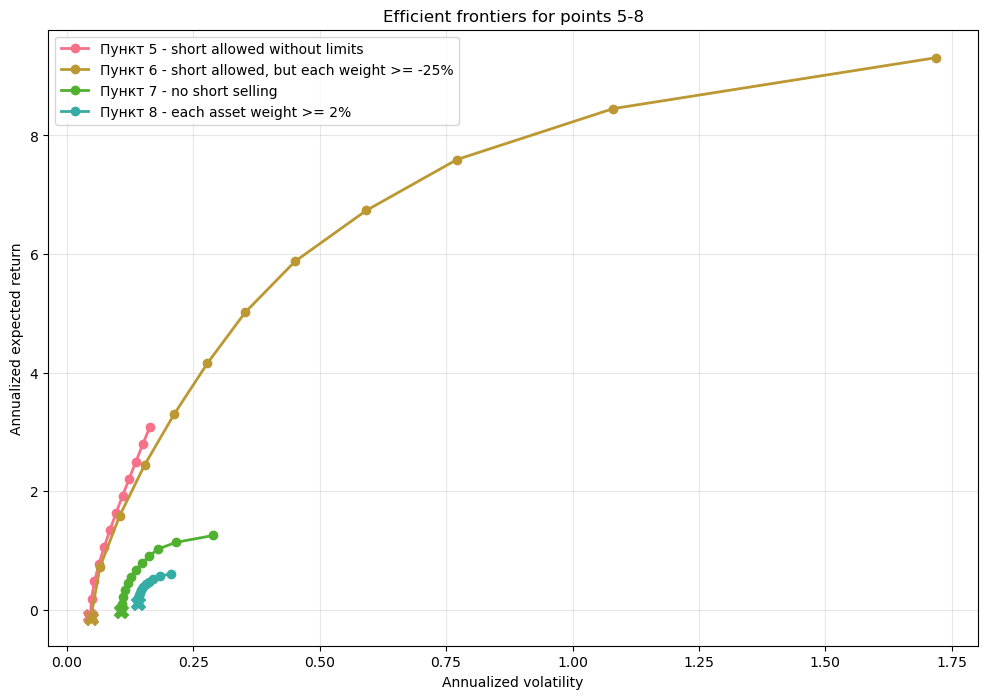

In [21]:
frontiers_4_8 = results_4_8['frontiers']
summaries_4_8 = results_4_8['summaries']

plt.figure(figsize=(12, 8))

for scenario_name, frontier_df in frontiers_4_8.items():
    plt.plot(
        frontier_df['portfolio_volatility'],
        frontier_df['portfolio_return'],
        marker='o',
        linewidth=2,
        label=scenario_name
    )

    gmv = summaries_4_8[scenario_name]
    plt.scatter(
        gmv['volatility'],
        gmv['return'],
        s=100,
        marker='X'
    )

plt.xlabel('Annualized volatility')
plt.ylabel('Annualized expected return')
plt.title('Efficient frontiers for points 5-8')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 4.4. Структура GMV-портфелей

In [22]:
for scenario_name, summary in summaries_4_8.items():
    print('=' * 80)
    print(f'Сценарий: {scenario_name}')
    print(f"GMV return: {summary['return']:.4f}")
    print(f"GMV volatility: {summary['volatility']:.4f}")
    print('Top-10 weights in GMV portfolio:')
    print(summary['weights'].head(10))
    print()

Сценарий: Пункт 5 - short allowed without limits
GMV return: -0.0954
GMV volatility: 0.0468
Top-10 weights in GMV portfolio:
SBERP    1.232359
AKRN     0.407890
CHMF     0.149221
SIBN     0.144895
TATNP    0.139940
MTSS     0.119795
ROSN     0.082959
PHOR     0.079056
BSPB     0.073451
IRAO     0.064005
dtype: float64

Сценарий: Пункт 6 - short allowed, but each weight >= -25%
GMV return: -0.1308
GMV volatility: 0.0475
Top-10 weights in GMV portfolio:
SBERP    0.892130
AKRN     0.388161
SIBN     0.159493
MTSS     0.154654
CHMF     0.118143
MAGN     0.091610
PHOR     0.079595
LSRG     0.073780
IRAO     0.072621
TATNP    0.062783
dtype: float64

Сценарий: Пункт 7 - no short selling
GMV return: -0.0157
GMV volatility: 0.1077
Top-10 weights in GMV portfolio:
AKRN     2.965112e-01
SBERP    2.931709e-01
BSPB     1.137750e-01
SNGSP    8.812304e-02
PHOR     7.802008e-02
LSRG     7.722352e-02
MTSS     3.990072e-02
FEES     1.327562e-02
LKOH     5.317666e-17
TATNP    3.447103e-17
dtype: float64


#### 4.5. Краткая интерпретация

Основная идея этого блока - показать, как ограничения меняют множество допустимых портфелей.

Типичная логика интерпретации:
- при **unrestricted short** optimizer имеет максимум свободы, поэтому граница обычно наиболее гибкая;
- при **short limit 25%** возможности хеджирования уменьшаются;
- при **no short** портфель становится более ограниченным и часто более концентрированным;
- при **minimum 2% in each asset** возникает вынужденная диверсификация, потому что optimizer обязан держать все акции хотя бы в малой доле.


### Общие выводы по блоку 4-8

1. Ограничения в optimizer заметно меняют эффективную границу и структуру оптимальных портфелей.  
2. Чем жестче ограничения на веса, тем уже множество достижимых портфелей.  
3. Наиболее свободный сценарий обычно дает минимальный риск за счет хеджирования.  
4. Наиболее жесткий сценарий с минимумом 2% в каждую бумагу часто приводит к вынужденной диверсификации и росту риска.


### 5. Скорректированные β и сравнение подходов к оценке covariance matrix

В этом разделе выполняются пункты 16-20 задания.

Чтобы сравнение было чистым, дальше фиксируем один и тот же сценарий optimizer:
- short selling разрешен без ограничений,
- сравнивается не постановка ограничений, а способ оценки covariance matrix.

**Выбор для пункта 12:**
- скользящее окно длиной 1 год,
- шаг 1 год,
- экспоненциальное забывание с `lambda = 0.94`,
- реально последнее доступное окно по последней дате выборки.

**Важно:**  
В текущем ноутбуке отдельный ряд рыночного индекса не загружен, поэтому для рабочего запуска ниже используется proxy market series - равновзвешенная средняя дневная доходность 30 акций.  
Если у вас есть отдельный ряд индекса, например IMOEX, его можно просто подставить вместо `proxy_market_returns`.


In [24]:
from task_16_20 import run_task_16_20

proxy_market_returns = returns.mean(axis=1)
market_label_16_20 = 'Proxy market - equal-weighted average return of 30 stocks'


#### 5.1. Запуск расчета для пунктов 16-20

In [25]:
results_16_20 = run_task_16_20(
    returns=returns,
    asset_names=list(returns.columns),
    market_returns=proxy_market_returns,
    market_label=market_label_16_20,
    window_method='rolling',
    window_size='1Y',
    step_size='1Y',
    lambda_param=0.94,
    n_points=12,
    selection_mode='latest',
    dynamic_window_method='rolling',
    dynamic_window_size='1Y',
    dynamic_step_size='1Y'
)

selected_window_16_20 = results_16_20['selected_window']

print("Выбранное окно и рыночный ряд:")
print(f"Метод окна: {results_16_20['config']['window_method']}")
print(f"Размер окна: {results_16_20['config']['window_size']}")
print(f"Шаг окна: {results_16_20['config']['step_size']}")
print(f"Режим выбора окна: {results_16_20['config']['selection_mode']}")
print(f"Lambda: {results_16_20['config']['lambda_param']}")
print(f"Источник рыночного ряда: {results_16_20['market_source']}")
print(f"Market label: {results_16_20['market_label']}")
print(f"Начало окна: {selected_window_16_20['window_start']}")
print(f"Конец окна: {selected_window_16_20['window_end']}")
print(f"Число наблюдений: {selected_window_16_20['window_n_obs']}")


Выбранное окно и рыночный ряд:
Метод окна: rolling
Размер окна: 1Y
Шаг окна: 1Y
Режим выбора окна: latest
Lambda: 0.94
Источник рыночного ряда: external_market_series
Market label: Proxy market - equal-weighted average return of 30 stocks
Начало окна: 2025-01-03 00:00:00
Конец окна: 2025-12-30 00:00:00
Число наблюдений: 250


#### 5.2. Historical β, adjusted β и фрагмент covariance matrix

Ниже показываем:
- таблицу оцененных beta на выбранном окне,
- фрагмент covariance matrix, построенной на adjusted beta.


In [26]:
beta_table_16_20 = results_16_20['beta_table_selected'].copy()
beta_table_16_20 = beta_table_16_20.sort_values('adjusted_beta', ascending=False)
beta_table_16_20.head(10)


,mean_return_daily,alpha_daily,historical_beta,adjusted_beta,residual_variance_daily
asset,,,,,
NVTK,0.001206,-0.000017,1.685439,1.456960,0.000055
TATN,-0.000513,-0.001696,1.630531,1.420354,0.000102
TATNP,-0.000500,-0.001670,1.611720,1.407813,0.000116
AFLT,0.001286,0.000122,1.604313,1.402875,0.000082
MAGN,0.002696,0.001738,1.320086,1.213391,0.000103
GAZP,-0.000124,-0.001075,1.310345,1.206897,0.000027
GMKN,0.004987,0.004083,1.245887,1.163925,0.000146
ALRS,0.000326,-0.000561,1.222364,1.148243,0.000144
NLMK,0.000678,-0.000163,1.158247,1.105498,0.000067


In [27]:
cov_adj_16_20 = pd.DataFrame(
    results_16_20['cov_matrices_selected_daily']['Adjusted betas'],
    index=returns.columns,
    columns=returns.columns
)

cov_adj_16_20.iloc[:10, :10]


,SBER,SBERP,GAZP,LKOH,ROSN,NVTK,TATN,TATNP,SNGS,SNGSP
SBER,0.000099,0.000075,0.000116,0.000099,0.000093,0.000140,0.000136,0.000135,0.000104,0.000071
SBERP,0.000075,0.000094,0.000114,0.000098,0.000092,0.000138,0.000135,0.000133,0.000102,0.000070
GAZP,0.000116,0.000114,0.000203,0.000150,0.000142,0.000213,0.000207,0.000206,0.000158,0.000108
LKOH,0.000099,0.000098,0.000150,0.000285,0.000121,0.000181,0.000177,0.000175,0.000135,0.000092
ROSN,0.000093,0.000092,0.000142,0.000121,0.000156,0.000172,0.000167,0.000166,0.000127,0.000087
NVTK,0.000140,0.000138,0.000213,0.000181,0.000172,0.000312,0.000250,0.000248,0.000191,0.000131
TATN,0.000136,0.000135,0.000207,0.000177,0.000167,0.000250,0.000346,0.000242,0.000186,0.000127
TATNP,0.000135,0.000133,0.000206,0.000175,0.000166,0.000248,0.000242,0.000355,0.000184,0.000126
SNGS,0.000104,0.000102,0.000158,0.000135,0.000127,0.000191,0.000186,0.000184,0.000221,0.000097
SNGSP,0.000071,0.000070,0.000108,0.000092,0.000087,0.000131,0.000127,0.000126,0.000097,0.000203


#### 5.3. Сравнение эффективных границ на выбранном окне

In [28]:
comparison_16_20 = results_16_20['comparison_selected']
comparison_16_20


,method,n_points,gmv_return,gmv_volatility,frontier_min_return,frontier_max_return,frontier_min_volatility,frontier_max_volatility,frontier_mode
0,Historical returns,12,-0.095351,0.046825,-0.095351,3.079419,0.046825,0.163887,visual_fragment_of_unbounded_frontier
1,Historical betas,12,-0.053024,0.067256,-0.053024,3.121745,0.067256,0.213934,visual_fragment_of_unbounded_frontier
2,Adjusted betas,12,-0.106007,0.091308,-0.106007,3.068763,0.091308,0.222205,visual_fragment_of_unbounded_frontier


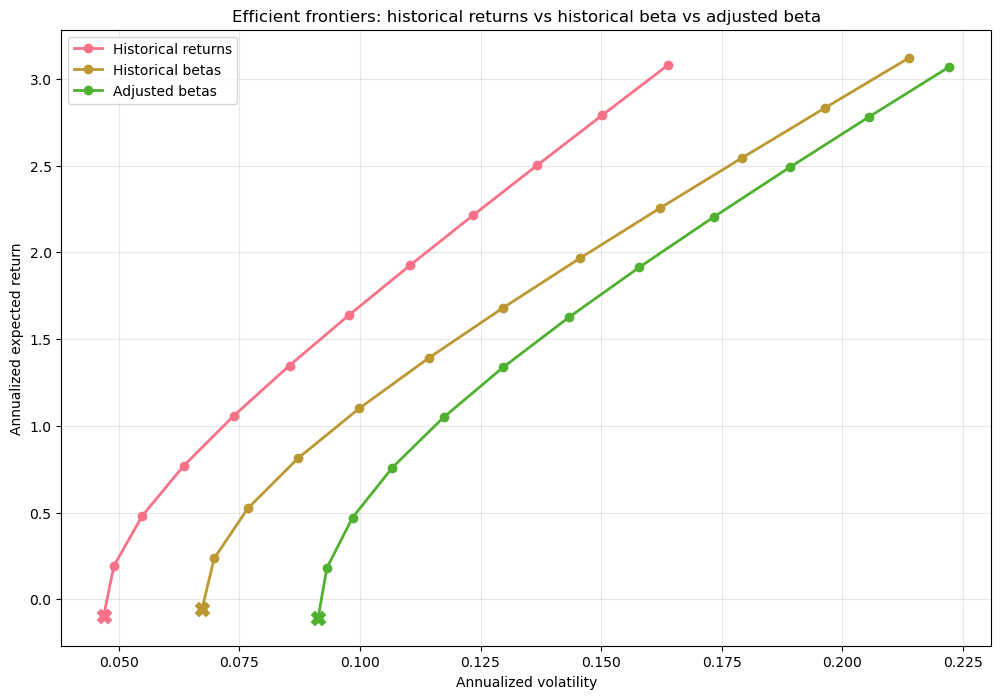

In [29]:
frontiers_16_20 = results_16_20['frontiers_selected']
summaries_16_20 = results_16_20['summaries_selected']

plt.figure(figsize=(12, 8))

for method_name, frontier_df in frontiers_16_20.items():
    plt.plot(
        frontier_df['portfolio_volatility'],
        frontier_df['portfolio_return'],
        marker='o',
        linewidth=2,
        label=method_name
    )

    gmv = summaries_16_20[method_name]
    plt.scatter(
        gmv['volatility'],
        gmv['return'],
        s=100,
        marker='X'
    )

plt.xlabel('Annualized volatility')
plt.ylabel('Annualized expected return')
plt.title('Efficient frontiers: historical returns vs historical beta vs adjusted beta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### 5.4. Динамика frontier на adjusted β по разным окнам

Этот график соответствует пункту 18: мы смотрим, как frontier на adjusted beta меняется от окна к окну.


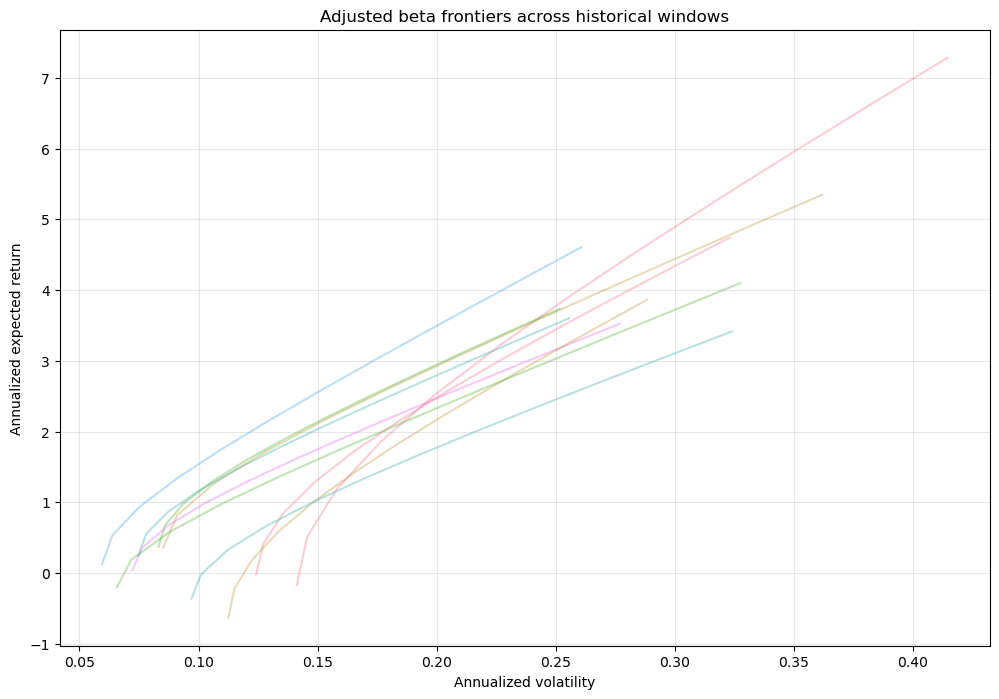

In [30]:
dynamic_frontiers_adj = results_16_20['dynamic_frontiers_by_method']['Adjusted betas']

plt.figure(figsize=(12, 8))

for window_end, frontier_df in dynamic_frontiers_adj.items():
    plt.plot(
        frontier_df['portfolio_volatility'],
        frontier_df['portfolio_return'],
        linewidth=1.5,
        alpha=0.35,
        label=str(window_end.date())
    )

plt.xlabel('Annualized volatility')
plt.ylabel('Annualized expected return')
plt.title('Adjusted beta frontiers across historical windows')
plt.grid(True, alpha=0.3)
plt.show()


#### 5.5. Сравнение методов по разным окнам

Здесь выполняется пункт 20: сравниваем три подхода не на одном окне, а в динамике.


In [31]:
dynamic_summary_16_20 = results_16_20['dynamic_summary']
dynamic_summary_16_20.head()


,window_end,window_start,method,gmv_return,gmv_volatility,frontier_max_return,frontier_max_volatility
0,2016-01-21,2015-01-22,Adjusted betas,-0.168696,0.141251,7.285011,0.414545
1,2016-01-21,2015-01-22,Historical betas,-0.177927,0.107609,7.275779,0.404337
2,2016-01-21,2015-01-22,Historical returns,0.295686,0.057177,7.749392,0.342260
3,2017-01-20,2016-01-22,Adjusted betas,0.361350,0.085184,5.347686,0.361851
4,2017-01-20,2016-01-22,Historical betas,0.334437,0.069675,5.320773,0.362512


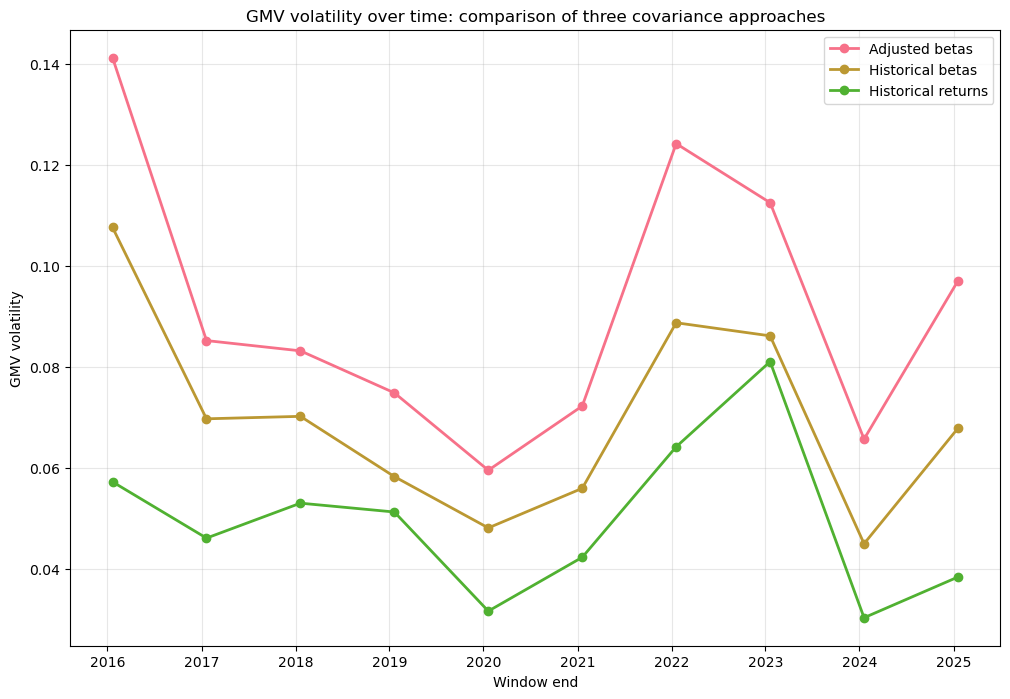

In [32]:
plt.figure(figsize=(12, 8))

for method_name in dynamic_summary_16_20['method'].unique():
    subset = dynamic_summary_16_20[dynamic_summary_16_20['method'] == method_name]
    plt.plot(
        subset['window_end'],
        subset['gmv_volatility'],
        marker='o',
        linewidth=2,
        label=method_name
    )

plt.xlabel('Window end')
plt.ylabel('GMV volatility')
plt.title('GMV volatility over time: comparison of three covariance approaches')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


На выбранном окне лучше всего сработал обычный подход через исторические доходности - там риск получился самым низким. Подход через historical beta дал результат похуже, а adjusted beta - самый осторожный и с самым высоким риском. 

Если смотреть на разные окна во времени, картина в целом повторяется. Обычный подход чаще дает более выгодный результат, а beta-подходы сильнее перестраховываются.

Итог такой: в наших данных historical returns оказались самым удачным вариантом, а adjusted beta - самым жестким.
